In [35]:
!pip install focal-loss

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

In [37]:
SEED = 24520152

In [38]:
tf.keras.utils.set_random_seed(SEED)

In [39]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [40]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [41]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [42]:
MODEL1_DIR = '/kaggle/input/mobilenet-ensemble/MobileNet_Ensemble'
MODEL1_DIR

'/kaggle/input/mobilenet-ensemble/MobileNet_Ensemble'

In [43]:
preprocess_fn1 = applications.mobilenet.preprocess_input

In [44]:
MODEL2_DIR = '/kaggle/input/vgg19-ensemble/VGG19_Ensemble'
MODEL2_DIR

'/kaggle/input/vgg19-ensemble/VGG19_Ensemble'

In [45]:
preprocess_fn2 = applications.vgg19.preprocess_input

In [46]:
def get_validation_fold(k, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    AUTOTUNE = tf.data.AUTOTUNE

    return val_ds

In [47]:
def tta_augmentation(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img

In [48]:
def tta_predict(model, preprocess_fn, ds, tta_rounds=5):
    AUTOTUNE = tf.data.AUTOTUNE
    
    val_ds = ds.map(lambda image, label: (preprocess_fn(image), label)).prefetch(AUTOTUNE)
    preds = [model.predict(val_ds)]

    for _ in range(tta_rounds):
        tta_ds = ds.map(lambda image, label: (tta_augmentation(image), label)).prefetch(AUTOTUNE)
        tta_ds = tta_ds.map(lambda image, label: (preprocess_fn(image), label)).prefetch(AUTOTUNE)
        preds.append(model.predict(tta_ds))

    preds = np.array(preds)
    return np.mean(preds, axis=0)

In [49]:
def test(val_ds, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    model1 = tf.keras.models.load_model(os.path.join(MODEL1_DIR, f'MobileNet_block_1_fold_{fold_k}.keras'))
    model2 = tf.keras.models.load_model(os.path.join(MODEL2_DIR, f'VGG19_block_1_fold_{fold_k}.keras'))

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    pred1 = tta_predict(model1, preprocess_fn1, val_ds)
    pred2 = tta_predict(model2, preprocess_fn2, val_ds)
    ensemble_pred = (pred1 + pred2) / 2.0
    y_pred = np.argmax(ensemble_pred, axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — Ensemble VGG19 - MobileNet')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    acc = accuracy_score(y_true, y_pred)

    del model1, model2, val_ds, y_true, pred1, pred2, ensemble_pred, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [50]:
acc = []

Fold: 1
Found 542 files belonging to 3 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 476ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      1.00      0.99       245
Meningioma Tumor       1.00      0.96      0.98       112
 Pituitary Tumor       0.99      1.00      1.00       185

        accuracy                           0.99       542
       macro avg       0.99      0.99      0.99       542
    weighted avg       0.99      0.99      0.99       542



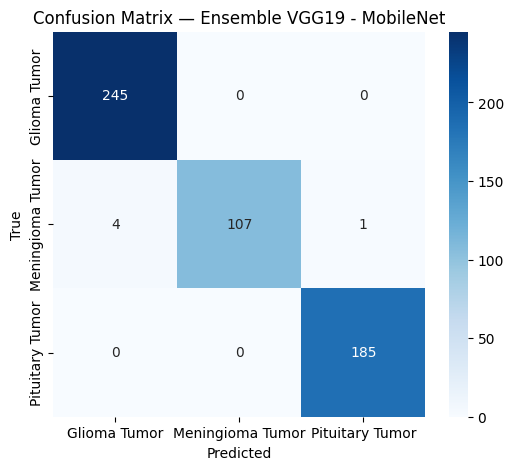

Fold: 2
Found 679 files belonging to 3 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.93      0.95       338
Meningioma Tumor       0.87      0.91      0.89       167
 Pituitary Tumor       0.94      0.97      0.95       174

        accuracy                           0.93       679
       macro avg       0.93      0.93      0.93       679
    weighted avg       0.93      0.93      0.93       679



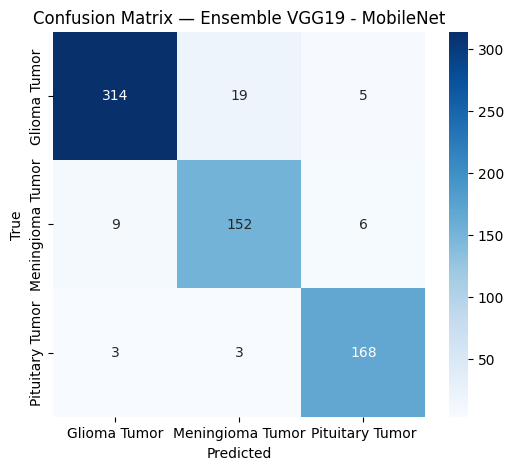

Fold: 3
Found 572 files belonging to 3 classes.
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 303ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 475ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.93      0.95       231
Meningioma Tumor       0.88      0.88      0.88       139
 Pituitary Tumor       0.95      1.00      0.98       202

        accuracy                           0.94       572
       macro avg       0.94      0.94      0.94       572
    weighted avg       0.94      0.94      0.94       572



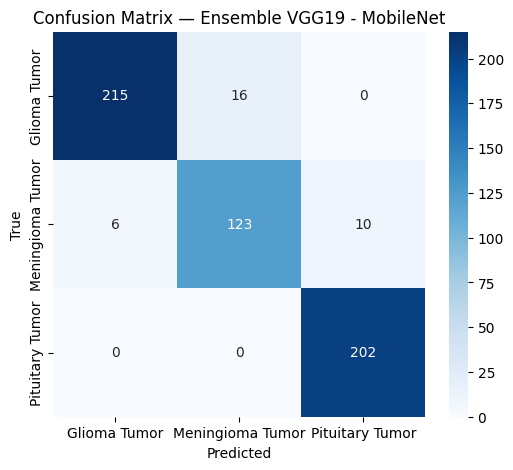

Fold: 4
Found 628 files belonging to 3 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 353ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      1.00      0.99       325
Meningioma Tumor       0.95      0.90      0.93       124
 Pituitary Tumor       0.96      0.96      0.96       179

        accuracy                           0.97       628
       macro avg       0.96      0.95      0.96       628
    weighted avg       0.97      0.97      0.97       628



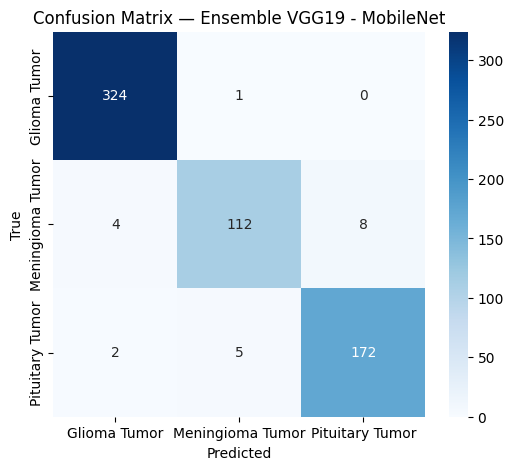

Fold: 5
Found 643 files belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.89      0.94       287
Meningioma Tumor       0.83      0.79      0.81       166
 Pituitary Tumor       0.84      0.99      0.91       190

        accuracy                           0.90       643
       macro avg       0.88      0.89      0.89       643
    weighted avg       0.90      0.90      0.90       643



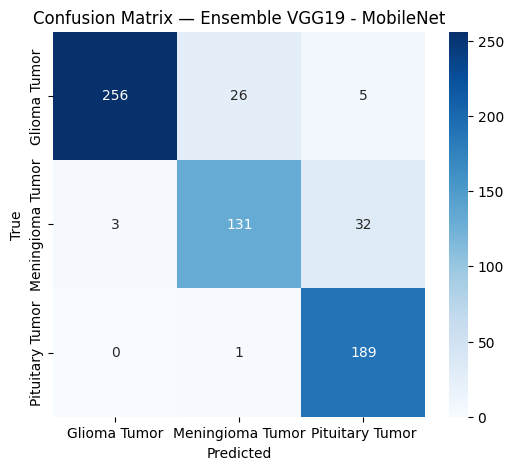

In [51]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k}')
    
    val_ds = get_validation_fold(fold_k)
    acc.append(test(val_ds, fold_k))

    del val_ds
    tf.keras.backend.clear_session()
    gc.collect()

In [52]:
print(f'Accuracy: {np.mean(acc) * 100:.2f}%')

Accuracy: 94.65%
